In [7]:
import numpy as np
import matplotlib.pyplot as plt
import adios2
import glob
import os
from tqdm import tqdm


# ======================================================
# 1. Find and sort all .bp files
# ======================================================

#path to simulation data
data_path = "/dartfs/rc/lab/E/EPaCO/phys118/Li/final_project/o_mode_periodic"
print("🔍 Searching for 'fields.*.bp' files...")
all_bp_files = sorted(glob.glob(os.path.join(data_path,"em_vacuum/fields/fields.*.bp")), key=lambda x: int(x.split(".")[1]))

print(f"✅ Found {len(all_bp_files)} files.")


🔍 Searching for 'fields.*.bp' files...
✅ Found 4526 files.


In [8]:
# ======================================================
# 2. Define variables and initialize global min/max
# ======================================================
field_vars = ["fE1", "fE2", "fE3", "fB1", "fB2", "fB3"]
global_min = {var: np.inf for var in field_vars}
global_max = {var: -np.inf for var in field_vars}

# ======================================================
# 3. Scan all files to find global min/max
# ======================================================
print("📊 Computing global min/max across all files...")

for file_path in tqdm(all_bp_files, desc="Scanning"):
    try:
        with adios2.Stream(file_path, "r") as s:
            s.begin_step()
            for var in field_vars:
                if var in s.available_variables():
                    data = s.read(var)
                    global_min[var] = min(global_min[var], np.min(data))
                    global_max[var] = max(global_max[var], np.max(data))
            s.end_step()
    except Exception as e:
        print(f"❌ Error processing {os.path.basename(file_path)}:\n{e}")

print("\n✅ Global min/max values:")
for var in field_vars:
    print(f"{var:>4} → min: {global_min[var]:.3e}, max: {global_max[var]:.3e}")



📊 Computing global min/max across all files...


Scanning: 100%|██████████| 4526/4526 [04:36<00:00, 16.34it/s]


✅ Global min/max values:
 fE1 → min: -1.156e-04, max: 1.158e-04
 fE2 → min: -1.152e-04, max: 1.159e-04
 fE3 → min: -4.466e-05, max: 4.426e-05
 fB1 → min: 9.999e-01, max: 1.000e+00
 fB2 → min: -5.702e-05, max: 5.542e-05
 fB3 → min: -1.525e-04, max: 1.528e-04



🎨 Plotting E · B for: fields.00000001.bp


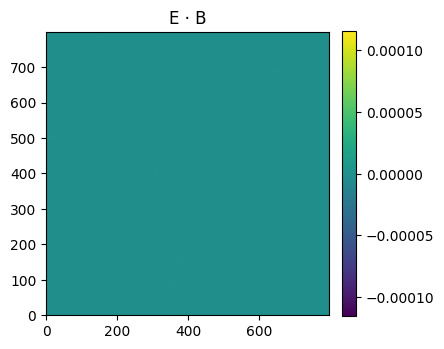


🎨 Plotting E · B for: fields.00010001.bp


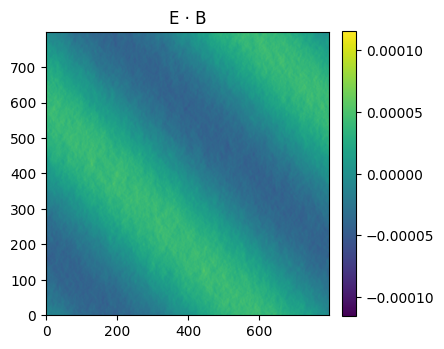


🎨 Plotting E · B for: fields.00050001.bp


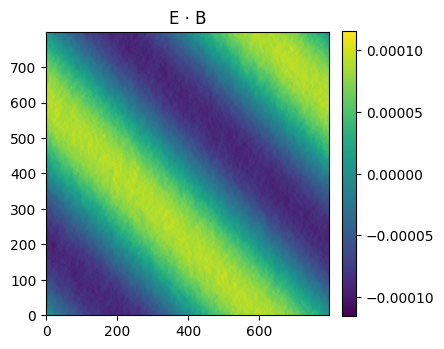


🎨 Plotting E · B for: fields.00100001.bp


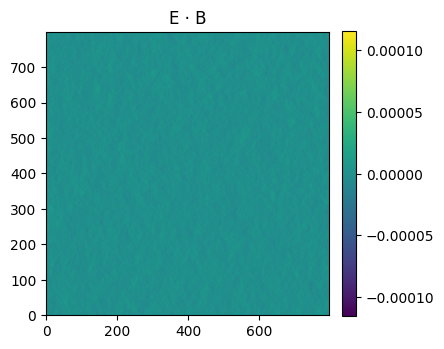


🎨 Plotting E · B for: fields.00452501.bp


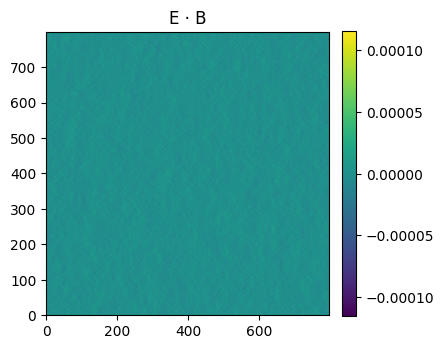

In [9]:
# ======================================================
#  Plot E · B
# ======================================================

indices = [0, 100, 500, 1000, len(all_bp_files)-1] # Choose which file to plot
for index in indices:
    file_path = all_bp_files[index]
    print(f"\n🎨 Plotting E · B for: {os.path.basename(file_path)}")

    try:
        # Read fields
        with adios2.Stream(file_path, "r") as s:
            s.begin_step()
            fE1 = np.array(s.read("fE1"))
            fE2 = np.array(s.read("fE2"))
            fE3 = np.array(s.read("fE3"))
            fB1 = np.array(s.read("fB1"))
            fB2 = np.array(s.read("fB2"))
            fB3 = np.array(s.read("fB3"))
            s.end_step()

        # Compute E · B
        E_dot_B = fE1*fB1 + fE2*fB2 + fE3*fB3

        # Plot
        plt.figure(figsize=(4,5))
        im = plt.imshow(
            E_dot_B,
            origin="lower",
            aspect=1,
            vmin=global_min["fE1"]*global_max["fB1"],  # rough scale
            vmax=global_max["fE1"]*global_max["fB1"]
        )
        plt.title("E · B")
        plt.colorbar(im, fraction=0.046, pad=0.04)
        plt.show()

    except Exception as e:
        print(f"⚠️ Error processing {os.path.basename(file_path)}:\n{e}")



🎨 Plotting E × B for: fields.00002601.bp


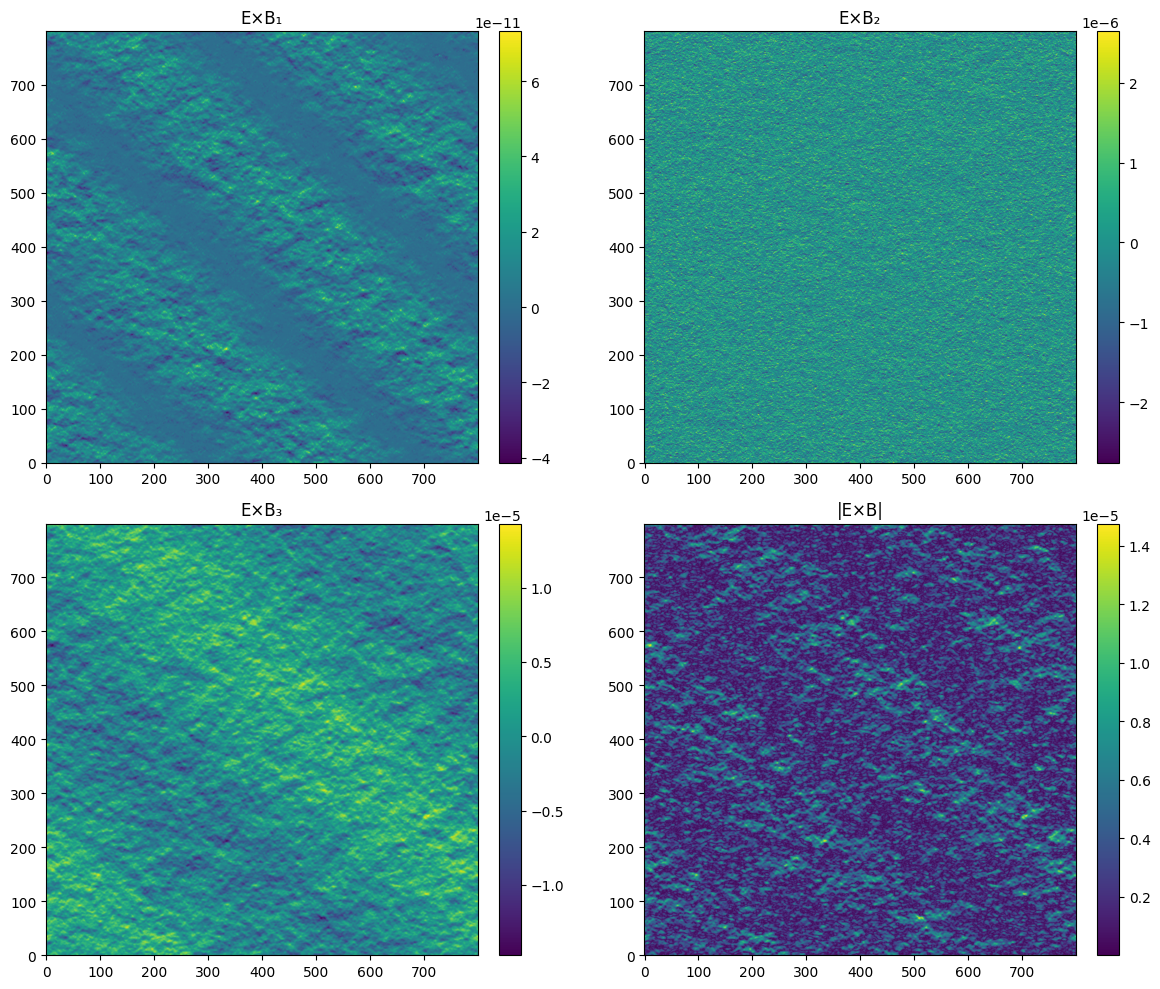

In [10]:
# ======================================================
#  Plot E × B 
# ======================================================

#index = 26  # same file as above
indices = [0, 100, 500, 1000, len(all_bp_files)-1]
file_path = all_bp_files[index]

print(f"\n🎨 Plotting E × B for: {os.path.basename(file_path)}")

try:
    with adios2.Stream(file_path, "r") as s:
        s.begin_step()
        fE1 = np.array(s.read("fE1"))
        fE2 = np.array(s.read("fE2"))
        fE3 = np.array(s.read("fE3"))
        fB1 = np.array(s.read("fB1"))
        fB2 = np.array(s.read("fB2"))
        fB3 = np.array(s.read("fB3"))
        s.end_step()

    # Compute E × B
    ExB1 = fE2*fB3 - fE3*fB2
    ExB2 = fE3*fB1 - fE1*fB3
    ExB3 = fE1*fB2 - fE2*fB1
    ExB_mag = np.sqrt(ExB1**2 + ExB2**2 + ExB3**2)

    datasets = [ExB1, ExB2, ExB3, ExB_mag]
    titles = ["E×B₁", "E×B₂", "E×B₃", "|E×B|"]

    fig, axes = plt.subplots(2,2, figsize=(12,10))
    axes = axes.flatten()

    for i, data in enumerate(datasets):
        im = axes[i].imshow(
            data,
            origin="lower",
            aspect=1,
            vmin=np.min(data),  # realistic min
            vmax=np.max(data)   # realistic max
        )
        axes[i].set_title(titles[i])
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"⚠️ Error processing {os.path.basename(file_path)}:\n{e}")



🎨 Plotting sum(abs(E · B)) for: fields.00009001.bp
Total sum(|E · B|) = 1.419e+01


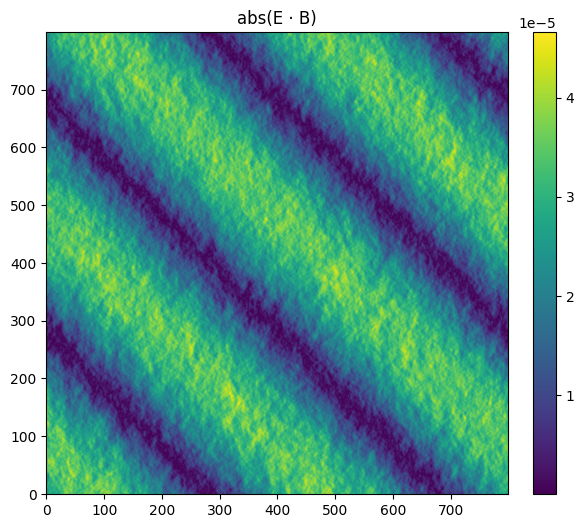

In [11]:
# ======================================================
# Cell 3: Plot sum(abs(E · B)) (corrected color scaling)
# ======================================================

index = 90 # same file
file_path = all_bp_files[index]

print(f"\n🎨 Plotting sum(abs(E · B)) for: {os.path.basename(file_path)}")

try:
    with adios2.Stream(file_path, "r") as s:
        s.begin_step()
        fE1 = np.array(s.read("fE1"))
        fE2 = np.array(s.read("fE2"))
        fE3 = np.array(s.read("fE3"))
        fB1 = np.array(s.read("fB1"))
        fB2 = np.array(s.read("fB2"))
        fB3 = np.array(s.read("fB3"))
        s.end_step()

    # Compute |E · B|
    E_dot_B_abs = np.abs(fE1*fB1 + fE2*fB2 + fE3*fB3)
    total_sum = np.sum(E_dot_B_abs)
    print(f"Total sum(|E · B|) = {total_sum:.3e}")

    # Plot
    plt.figure(figsize=(8,6))
    im = plt.imshow(
        E_dot_B_abs,
        origin="lower",
        aspect=1,
        vmin=np.min(E_dot_B_abs),
        vmax=np.max(E_dot_B_abs)
    )
    plt.title("abs(E · B)")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.show()

except Exception as e:
    print(f"⚠️ Error processing {os.path.basename(file_path)}:\n{e}")



🎨 Plotting file: fields.00009001.bp


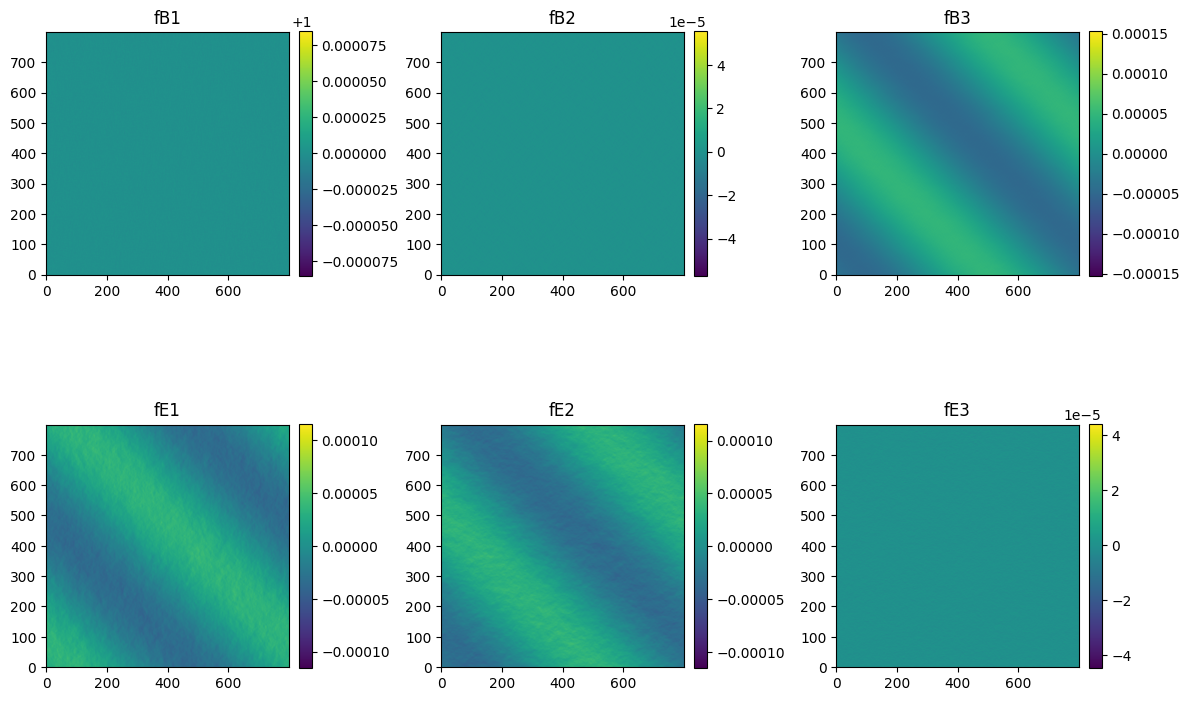

In [13]:
# ======================================================
# 4. Plot E and B with consistent color scales
# ======================================================

index = 90  # change this to pick a different file
file_path = all_bp_files[index]

print(f"\n🎨 Plotting file: {os.path.basename(file_path)}")

try:
    with adios2.Stream(file_path, "r") as s:
        s.begin_step()
        fE1, fE2, fE3 = [s.read(v) for v in ["fE1", "fE2", "fE3"]]
        fB1, fB2, fB3 = [s.read(v) for v in ["fB1", "fB2", "fB3"]]
        s.end_step()

    # Arrange data for plotting
    datasets = [[fB1, fB2, fB3],
                [fE1, fE2, fE3]]

    titles = [["fB1", "fB2", "fB3"],
              ["fE1", "fE2", "fE3"]]

    # Create the plot
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for i in range(2):
        for j in range(3):
            var = titles[i][j]
            im = axes[i, j].imshow(
                datasets[i][j],
                origin="lower",
                aspect=1,
                vmin=global_min[var],
                vmax=global_max[var]
            )
            axes[i, j].set_title(var)
            plt.colorbar(im, ax=axes[i, j], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    # Optional: save figure
    # out_name = f"{os.path.splitext(os.path.basename(file_path))[0]}_fields.jpg"
    # plt.savefig(out_name, bbox_inches="tight", dpi=300)
    # print(f"💾 Saved: {out_name}")

except Exception as e:
    print(f"⚠️ Error plotting {os.path.basename(file_path)}:\n{e}")


In [14]:
# ======================================================
# Batch save E×B and E·B plots with realistic global color scales
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
import adios2
import os

# --- File range ---
start_index = 100
end_index = 120
output_dir = "plots"
os.makedirs(output_dir, exist_ok=True)

print(f"\n🎨 Saving files {start_index}–{end_index-1} to '{output_dir}/'")

# --- Step 1: Compute realistic global min/max for derived quantities ---
ExB_min = np.inf
ExB_max = -np.inf
ExB_mag_max = -np.inf
EdotB_min = np.inf
EdotB_max = -np.inf
EdotB_abs_max = -np.inf

print("📊 Scanning files for global min/max of derived quantities...")

for file_path in all_bp_files[start_index:end_index]:
    try:
        with adios2.Stream(file_path, "r") as s:
            s.begin_step()
            fE1, fE2, fE3 = [np.array(s.read(v)) for v in ["fE1","fE2","fE3"]]
            fB1, fB2, fB3 = [np.array(s.read(v)) for v in ["fB1","fB2","fB3"]]
            s.end_step()
    except Exception as e:
        print(f"⚠️ Error reading {file_path}:\n{e}")
        continue

    ExB1 = fE2*fB3 - fE3*fB2
    ExB2 = fE3*fB1 - fE1*fB3
    ExB3 = fE1*fB2 - fE2*fB1
    ExB_mag = np.sqrt(ExB1**2 + ExB2**2 + ExB3**2)
    E_dot_B = fE1*fB1 + fE2*fB2 + fE3*fB3
    E_dot_B_abs = np.abs(E_dot_B)

    ExB_min = min(ExB_min, ExB1.min(), ExB2.min(), ExB3.min())
    ExB_max = max(ExB_max, ExB1.max(), ExB2.max(), ExB3.max())
    ExB_mag_max = max(ExB_mag_max, ExB_mag.max())
    EdotB_min = min(EdotB_min, E_dot_B.min())
    EdotB_max = max(EdotB_max, E_dot_B.max())
    EdotB_abs_max = max(EdotB_abs_max, E_dot_B_abs.max())

print(f"✅ Done scanning. Derived quantity ranges:")
print(f"E×B components → min: {ExB_min:.3e}, max: {ExB_max:.3e}")
print(f"|E×B| → max: {ExB_mag_max:.3e}")
print(f"E·B → min: {EdotB_min:.3e}, max: {EdotB_max:.3e}")
print(f"|E·B| → max: {EdotB_abs_max:.3e}")

# --- Step 2: Loop over files and save figures ---
for index in range(start_index, end_index):
    file_path = all_bp_files[index]
    file_name = os.path.basename(file_path)
    print(f"\n🖼️ Processing: {file_name}")

    try:
        # Read fields
        with adios2.Stream(file_path, "r") as s:
            s.begin_step()
            fE1, fE2, fE3 = [np.array(s.read(v)) for v in ["fE1","fE2","fE3"]]
            fB1, fB2, fB3 = [np.array(s.read(v)) for v in ["fB1","fB2","fB3"]]
            s.end_step()

        # Compute E×B and E·B
        ExB1 = fE2*fB3 - fE3*fB2
        ExB2 = fE3*fB1 - fE1*fB3
        ExB3 = fE1*fB2 - fE2*fB1
        ExB_mag = np.sqrt(ExB1**2 + ExB2**2 + ExB3**2)

        E_dot_B = fE1*fB1 + fE2*fB2 + fE3*fB3
        E_dot_B_abs = np.abs(E_dot_B)
        total_sum_abs = np.sum(E_dot_B_abs)

        # Organize datasets and titles
        datasets = [[ExB1, ExB2, ExB3],
                    [ExB_mag, E_dot_B, E_dot_B_abs]]
        titles = [["E×B₁", "E×B₂", "E×B₃"],
                  ["|E×B|", "E·B", "|E·B|"]]

        # Create figure
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        for i in range(2):
            for j in range(3):
                data = datasets[i][j]
                title = titles[i][j]

                # Assign color scales
                if i == 0 and j < 3:       # E×B components
                    vmin, vmax = ExB_min, ExB_max
                elif i == 1 and j == 0:    # |E×B|
                    vmin, vmax = 0, ExB_mag_max
                elif i == 1 and j == 1:    # E·B
                    vmin, vmax = EdotB_min, EdotB_max
                else:                       # |E·B|
                    vmin, vmax = 0, EdotB_abs_max

                im = axes[i,j].imshow(
                    data,
                    origin="lower",
                    aspect=1,
                    vmin=vmin,
                    vmax=vmax
                )
                axes[i,j].set_title(title)
                plt.colorbar(im, ax=axes[i,j], fraction=0.046, pad=0.04)

        # Add total sum(|E·B|) as title
        fig.suptitle(f"Total sum(|E·B|) = {total_sum_abs:.3e}", fontsize=14, y=1.02)

        plt.tight_layout()

        # Save figure
        out_name = os.path.join(output_dir, f"{file_name}.jpg")
        plt.savefig(out_name, bbox_inches="tight", dpi=300)
        plt.close()
        print(f"💾 Saved: {out_name}")

    except Exception as e:
        print(f"⚠️ Error plotting {file_name}:\n{e}")

print("\n✅ Done saving selected range!")



🎨 Saving files 100–119 to 'plots/'
📊 Scanning files for global min/max of derived quantities...
✅ Done scanning. Derived quantity ranges:
E×B components → min: -6.606e-05, max: 6.631e-05
|E×B| → max: 6.632e-05
E·B → min: -6.497e-05, max: 6.622e-05
|E·B| → max: 6.622e-05

🖼️ Processing: fields.00010001.bp
💾 Saved: plots/fields.00010001.bp.jpg

🖼️ Processing: fields.00010101.bp
💾 Saved: plots/fields.00010101.bp.jpg

🖼️ Processing: fields.00010201.bp
💾 Saved: plots/fields.00010201.bp.jpg

🖼️ Processing: fields.00010301.bp
💾 Saved: plots/fields.00010301.bp.jpg

🖼️ Processing: fields.00010401.bp
💾 Saved: plots/fields.00010401.bp.jpg

🖼️ Processing: fields.00010501.bp
💾 Saved: plots/fields.00010501.bp.jpg

🖼️ Processing: fields.00010601.bp
💾 Saved: plots/fields.00010601.bp.jpg

🖼️ Processing: fields.00010701.bp
💾 Saved: plots/fields.00010701.bp.jpg

🖼️ Processing: fields.00010801.bp
💾 Saved: plots/fields.00010801.bp.jpg

🖼️ Processing: fields.00010901.bp
💾 Saved: plots/fields.00010901.bp.jp

In [13]:
# ======================================================
# 5. Plot and save a RANGE of files with consistent color scales
# ======================================================

# Choose the file range to save
start_index = 100   # inclusive
end_index   = 120   # exclusive → saves files 20–50
output_dir = "plots"
os.makedirs(output_dir, exist_ok=True)

print(f"\n🎨 Saving files {start_index}–{end_index-1} to '{output_dir}/'")

for index in range(start_index, end_index):
    file_path = all_bp_files[index]
    file_name = os.path.basename(file_path)
    print(f"🖼️ Processing: {file_name}")

    try:
        with adios2.Stream(file_path, "r") as s:
            s.begin_step()
            fE1, fE2, fE3 = [s.read(v) for v in ["fE1", "fE2", "fE3"]]
            fB1, fB2, fB3 = [s.read(v) for v in ["fB1", "fB2", "fB3"]]
            s.end_step()

        datasets = [[fB1, fB2, fB3],
                    [fE1, fE2, fE3]]
        titles = [["fB1", "fB2", "fB3"],
                  ["fE1", "fE2", "fE3"]]

        fig, axes = plt.subplots(2, 3, figsize=(12, 8))
        for i in range(2):
            for j in range(3):
                var = titles[i][j]
                im = axes[i, j].imshow(
                    datasets[i][j],
                    origin="lower",
                    aspect=1,
                    vmin=global_min[var],
                    vmax=global_max[var]
                )
                axes[i, j].set_title(var)
                plt.colorbar(im, ax=axes[i, j], fraction=0.046, pad=0.04)

        plt.tight_layout()

        # Save using the .bp file’s name (e.g., fields.00000020.bp.jpg)
        out_name = os.path.join(output_dir, f"{file_name}.jpg")
        plt.savefig(out_name, bbox_inches="tight", dpi=300)
        plt.close()
        print(f"💾 Saved: {out_name}")

    except Exception as e:
        print(f"⚠️ Error plotting {file_name}:\n{e}")

print("\n✅ Done saving selected range!")



🎨 Saving files 100–119 to 'plots/'
🖼️ Processing: fields.00010001.bp
💾 Saved: plots/fields.00010001.bp.jpg
🖼️ Processing: fields.00010101.bp
💾 Saved: plots/fields.00010101.bp.jpg
🖼️ Processing: fields.00010201.bp
💾 Saved: plots/fields.00010201.bp.jpg
🖼️ Processing: fields.00010301.bp
💾 Saved: plots/fields.00010301.bp.jpg
🖼️ Processing: fields.00010401.bp
💾 Saved: plots/fields.00010401.bp.jpg
🖼️ Processing: fields.00010501.bp
💾 Saved: plots/fields.00010501.bp.jpg
🖼️ Processing: fields.00010601.bp
💾 Saved: plots/fields.00010601.bp.jpg
🖼️ Processing: fields.00010701.bp
💾 Saved: plots/fields.00010701.bp.jpg
🖼️ Processing: fields.00010801.bp
💾 Saved: plots/fields.00010801.bp.jpg
🖼️ Processing: fields.00010901.bp
💾 Saved: plots/fields.00010901.bp.jpg
🖼️ Processing: fields.00011001.bp
💾 Saved: plots/fields.00011001.bp.jpg
🖼️ Processing: fields.00011101.bp
💾 Saved: plots/fields.00011101.bp.jpg
🖼️ Processing: fields.00011201.bp
💾 Saved: plots/fields.00011201.bp.jpg
🖼️ Processing: fields.000113

In [15]:
import adios2

file_path = all_bp_files[0]  # or pick any file
with adios2.Stream(file_path, "r") as s:
    s.begin_step()
    vars_in_file = list(s.available_variables().keys())
    s.end_step()

print("Variables in file:", vars_in_file)

Variables in file: ['N1l', 'N2l', 'Step', 'Time', 'X1', 'X1e', 'X2', 'X2e', 'fB1', 'fB2', 'fB3', 'fE1', 'fE2', 'fE3', 'fJ1', 'fJ2', 'fJ3', 'fN']
